In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os
import json
import glob
from pathlib import Path
from tqdm import tqdm
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import KFold
import math
import random

# --- 1. CONFIGURATION ---
CONFIG = {
    # Data Paths
    'base_data_path': '/content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data',
    'input_directory': 'GridTransitionDataset/training_transformed_unique_ids',
    'output_directory': '/content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/models', # Added output directory

    # Model Hyperparameters
    'vocab_size': 12,
    'max_seq_len': 1802,
    'd_model': 2,
    'nhead': 2,
    'num_layers': 1,
    'dim_feedforward': 128,
    'dropout': 0.1,

    # Training Parameters
    'batch_size': 1,
    'learning_rate_g': 0.0002,
    'learning_rate_d': 0.0002,
    'num_epochs': 1,
    'n_splits': 2,
    'train_generator_every': 1,
}

# --- 2. DATASET CLASS ---
class ARCDataset(Dataset):
    def __init__(self, file_paths):
        self.file_paths = file_paths

    def __len__(self):
        return len(self.file_paths)

    def __getitem__(self, idx):
        file_path = self.file_paths[idx]

        try:
            with open(file_path, 'r') as f:
                task = json.load(f)
        except Exception as e:
            print(f"Error loading JSON from {file_path}: {e}")
            return None # Return None for corrupted or unreadable files

        input_grid_data = None
        output_grid_data = None

        # Try to load from the 'train' key first
        if 'train' in task and task['train']:
            example = task['train'][0]
            if 'input' in example and example['input'] and 'output' in example and example['output']:
                input_grid_data = example['input']
                output_grid_data = example['output']
        # If 'train' key is not suitable or empty, try to load from top-level 'input' and 'output'
        elif 'input' in task and task['input'] and 'output' in task and task['output']:
             input_grid_data = task['input']
             output_grid_data = task['output']


        if input_grid_data is None or output_grid_data is None:
             print(f"Warning: 'input' or 'output' data not found or is empty in expected structure in {file_path}. Skipping this file.")
             return None # Return None if 'input' or 'output' keys are missing or empty in both structures

        input_grid = np.array(input_grid_data)
        output_grid = np.array(output_grid_data)


        # Flatten and concatenate the grids
        start_token, sep_token = 10, 11
        input_flat = input_grid.flatten()
        output_flat = output_grid.flatten()

        sequence = np.concatenate([
            [start_token],
            input_flat,
            [sep_token],
            output_flat
        ])

        # Pad sequence to max length
        # If the sequence is longer than max_seq_len, truncate it.
        if len(sequence) > CONFIG['max_seq_len']:
             sequence = sequence[:CONFIG['max_seq_len']]
             print(f"Warning: Sequence length exceeded max_seq_len in {file_path}. Truncating.")


        padded_sequence = np.pad(sequence, (0, CONFIG['max_seq_len'] - len(sequence)), 'constant', constant_values=0)

        return torch.tensor(padded_sequence, dtype=torch.long)

# Custom collate function to filter out None values
def collate_fn(batch):
    batch = [item for item in batch if item is not None]
    if not batch:
        return None # Return None if the batch is empty after filtering
    return torch.stack(batch, 0)


# --- 3. MODEL ARCHITECTURE ---
class Generator(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_feedforward, dropout):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.output_layer = nn.Linear(d_model, vocab_size)

    def forward(self, src):
        # src is expected to be a LongTensor of token indices
        src = self.token_embedding(src)
        output = self.transformer_encoder(src)
        logits = self.output_layer(output)
        # Apply Gumbel-Softmax for discrete token generation in a separate step
        return logits

class Discriminator(nn.Module):
    def __init__(self, vocab_size, d_model, nhead, num_layers, dim_feedforward, dropout):
        super().__init__()
        self.token_embedding = nn.Embedding(vocab_size, d_model)
        encoder_layer = nn.TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout, batch_first=True)
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers)
        self.output_layer = nn.Linear(d_model, 1)

    def forward(self, src):
        # src is expected to be a LongTensor of token indices
        src = self.token_embedding(src)
        output = self.transformer_encoder(src)
        output = torch.mean(output, dim=1)
        return self.output_layer(output)

# --- 4. WEIGHTS INITIALIZATION ---
def weights_init(m):
    if isinstance(m, nn.Linear):
        # Initialize weights with Xavier uniform, biases with constant 0
        nn.init.xavier_uniform_(m.weight)
        if m.bias is not None:
            nn.init.constant_(m.bias, 0)
    elif isinstance(m, nn.TransformerEncoderLayer):
        # Initialize weights with Xavier uniform, biases with constant 0
        for name, param in m.named_parameters():
            if 'weight' in name:
                if param.dim() >= 2: # Only initialize weights with more than one dimension
                  nn.init.xavier_uniform_(param)
            elif 'bias' in name:
                nn.init.constant_(param, 0)
    elif isinstance(m, nn.Embedding):
        # Initialize embedding weights (optional, often left as default)
        nn.init.xavier_uniform_(m.weight)


# --- 5. TRAINER CLASS ---
class GANTrainer:
    def __init__(self, config):
        self.config = config
        self.device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

        # Create output directory if it doesn't exist
        os.makedirs(self.config['output_directory'], exist_ok=True)

        # FIX: Collect full file paths, not just basenames
        file_path_iterator = glob.iglob(
            os.path.join(self.config['base_data_path'], self.config['input_directory'], '**', '*.json'),
            recursive=True
        )
        self.all_file_paths = list(file_path_iterator)
        print(f"Total files found: {len(self.all_file_paths)}")

    def run_cross_validation(self):
        k_fold = KFold(n_splits=self.config['n_splits'], shuffle=True, random_state=42)

        fold_discriminator_losses = []
        fold_generator_losses = []

        for fold, (train_ids, val_ids) in enumerate(k_fold.split(self.all_file_paths)):
            print(f"--- FOLD {fold+1}/{self.config['n_splits']} ---")

            generator = Generator(
                self.config['vocab_size'], self.config['d_model'], self.config['nhead'],
                self.config['num_layers'], self.config['dim_feedforward'], self.config['dropout']
            ).to(self.device)
            discriminator = Discriminator(
                self.config['vocab_size'], self.config['d_model'], self.config['nhead'],
                self.config['num_layers'], self.config['dim_feedforward'], self.config['dropout']
            ).to(self.device)

            generator.apply(weights_init)
            discriminator.apply(weights_init)

            optimizer_G = optim.Adam(generator.parameters(), lr=self.config['learning_rate_g'])
            optimizer_D = optim.Adam(discriminator.parameters(), lr=self.config['learning_rate_d'])
            criterion = nn.BCEWithLogitsLoss()

            train_subsampler = torch.utils.data.SubsetRandomSampler(train_ids)
            val_subsampler = torch.utils.data.SubsetRandomSampler(val_ids)

            # FIX: Pass the correct file paths to the Dataset
            dataset = ARCDataset(self.all_file_paths)

            train_loader = DataLoader(dataset, batch_size=self.config['batch_size'], sampler=train_subsampler, collate_fn=collate_fn)
            val_loader = DataLoader(dataset, batch_size=self.config['batch_size'], sampler=val_subsampler, collate_fn=collate_fn)

            avg_fold_disc_loss, avg_fold_gen_loss = self.train_gan(generator, discriminator, optimizer_G, optimizer_D, criterion, train_loader)

            fold_discriminator_losses.append(avg_fold_disc_loss)
            fold_generator_losses.append(avg_fold_gen_loss)

            # Save models for each fold
            self.save_models(generator, discriminator, fold + 1)


        print("\n--- Cross-Validation Results ---")
        avg_disc_loss_cv = sum(fold_discriminator_losses) / self.config['n_splits']
        avg_gen_loss_cv = sum(fold_generator_losses) / self.config['n_splits']
        print(f"Average Discriminator Loss across {self.config['n_splits']} folds: {avg_disc_loss_cv:.4f}")
        print(f"Average Generator Loss across {self.config['n_splits']} folds: {avg_gen_loss_cv:.4f}")

        # Save cross-validation results
        self.save_results(fold_discriminator_losses, fold_generator_losses, avg_disc_loss_cv, avg_gen_loss_cv)


    def train_gan(self, generator, discriminator, optimizer_G, optimizer_D, criterion, data_loader):
        fold_disc_losses_epoch = []
        fold_gen_losses_epoch = []
        g_loss = None # Initialize g_loss

        for epoch in range(self.config['num_epochs']):
            for i, real_sequences in enumerate(tqdm(data_loader, desc=f"Epoch {epoch+1}/{self.config['num_epochs']}")):
                # Skip if the batch is None (happens if all items in the batch were filtered out)
                if real_sequences is None:
                    continue

                real_sequences = real_sequences.to(self.device)
                batch_size = real_sequences.size(0)

                # --- Train Discriminator ---
                discriminator.zero_grad()

                # Train with real data
                real_labels = torch.ones(batch_size, 1, device=self.device)
                d_output_real = discriminator(real_sequences)
                d_loss_real = criterion(d_output_real, real_labels)
                d_loss_real.backward()

                # --- Train with fake data ---
                # FIX: Generate random LongTensor indices as input to the generator
                # Assuming the generator takes token indices as input.
                fake_input_indices = torch.randint(0, self.config['vocab_size'], (batch_size, self.config['max_seq_len']), dtype=torch.long, device=self.device)
                fake_sequences_logits = generator(fake_input_indices) # Pass LongTensor indices to the generator

                # Apply Gumbel-Softmax to get discrete tokens.
                # Use argmax to get the indices that the discriminator expects.
                fake_sequences_one_hot = F.gumbel_softmax(fake_sequences_logits, tau=0.5, hard=True, dim=-1)
                fake_sequences = torch.argmax(fake_sequences_one_hot, dim=-1)

                fake_labels = torch.zeros(batch_size, 1, device=self.device)
                d_output_fake = discriminator(fake_sequences)
                d_loss_fake = criterion(d_output_fake, fake_labels)
                d_loss_fake.backward()

                # Update Discriminator weights
                d_loss = d_loss_real + d_loss_fake
                optimizer_D.step()

                # --- Train Generator ---
                if i % self.config['train_generator_every'] == 0:
                    generator.zero_grad()
                    gen_labels = torch.ones(batch_size, 1, device=self.device)
                    # FIX: Train the generator using random LongTensor indices as input
                    fake_input_indices_gen = torch.randint(0, self.config['vocab_size'], (batch_size, self.config['max_seq_len']), dtype=torch.long, device=self.device)
                    fake_sequences_logits_gen = generator(fake_input_indices_gen)
                    # The discriminator needs the output of the Gumbel-Softmax as integer indices
                    fake_sequences_gen = torch.argmax(F.gumbel_softmax(fake_sequences_logits_gen, tau=0.5, hard=True, dim=-1), dim=-1)
                    g_output = discriminator(fake_sequences_gen)
                    g_loss = criterion(g_output, gen_labels)
                    g_loss.backward()
                    optimizer_G.step()

            fold_disc_losses_epoch.append(d_loss.item())
            # Only append g_loss if it was calculated in the epoch
            if g_loss is not None:
                fold_gen_losses_epoch.append(g_loss.item())


        avg_fold_discriminator_loss = sum(fold_disc_losses_epoch) / len(fold_disc_losses_epoch)
        # Calculate average generator loss only if there are entries in fold_gen_losses_epoch
        avg_fold_generator_loss = sum(fold_gen_losses_epoch) / len(fold_gen_losses_epoch) if fold_gen_losses_epoch else 0

        print(f"--- Finished Fold ---")
        print(f"Average Discriminator Loss: {avg_fold_discriminator_loss:.4f}")
        print(f"Average Generator Loss: {avg_fold_generator_loss:.4f}")

        return avg_fold_discriminator_loss, avg_fold_generator_loss

    def save_models(self, generator, discriminator, fold):
        """Saves the generator and discriminator models."""
        generator_path = os.path.join(self.config['output_directory'], f'generator_fold_{fold}.pth')
        discriminator_path = os.path.join(self.config['output_directory'], f'discriminator_fold_{fold}.pth')
        torch.save(generator.state_dict(), generator_path)
        torch.save(discriminator.state_dict(), discriminator_path)
        print(f"Saved models for fold {fold} to {generator_path} and {discriminator_path}")

    def save_results(self, fold_discriminator_losses, fold_generator_losses, avg_disc_loss_cv, avg_gen_loss_cv):
        """Saves the cross-validation results to a JSON file."""
        results = {
            'fold_discriminator_losses': fold_discriminator_losses,
            'fold_generator_losses': fold_generator_losses,
            'average_discriminator_loss_cv': avg_disc_loss_cv,
            'average_generator_loss_cv': avg_gen_loss_cv,
            'config': self.config # Include config for reproducibility
        }
        results_path = os.path.join(self.config['output_directory'], 'cross_validation_results.json')
        with open(results_path, 'w') as f:
            json.dump(results, f, indent=4)
        print(f"Saved cross-validation results to {results_path}")


# --- 6. MAIN EXECUTION ---
if __name__ == '__main__':
    trainer = GANTrainer(CONFIG)
    trainer.run_cross_validation()

Total files found: 16144
--- FOLD 1/2 ---


Epoch 1/1: 100%|██████████| 8072/8072 [2:45:02<00:00,  1.23s/it]


--- Finished Fold ---
Average Discriminator Loss: 0.3868
Average Generator Loss: 1.6817
Saved models for fold 1 to /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/models/generator_fold_1.pth and /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/models/discriminator_fold_1.pth
--- FOLD 2/2 ---


Epoch 1/1: 100%|██████████| 8072/8072 [2:46:57<00:00,  1.24s/it]

--- Finished Fold ---
Average Discriminator Loss: 0.1269
Average Generator Loss: 2.0717
Saved models for fold 2 to /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/models/generator_fold_2.pth and /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/models/discriminator_fold_2.pth

--- Cross-Validation Results ---
Average Discriminator Loss across 2 folds: 0.2568
Average Generator Loss across 2 folds: 1.8767
Saved cross-validation results to /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/models/cross_validation_results.json


In [ ]:
!ls /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data/GridTransitionDataset/training_transformed_unique_ids

In [ ]:
!cat /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/data/GridTransitionDataset/training_transformed_unique_ids/6d13bf4a-1068-40de-aa2b-030b51be212b.json

### Visualize Training Results

First, let's load the cross-validation results from the saved JSON file.

In [8]:
import json
import os

# Assuming CONFIG is already defined and contains output_directory
results_path = os.path.join(CONFIG['output_directory'], 'cross_validation_results.json')

try:
    with open(results_path, 'r') as f:
        cross_validation_results = json.load(f)
    print("Cross-validation results loaded successfully.")
    # You can inspect the loaded data:
    # print(cross_validation_results)
except FileNotFoundError:
    print(f"Error: Results file not found at {results_path}")
except Exception as e:
    print(f"Error loading results from {results_path}: {e}")

Cross-validation results loaded successfully.


Now, let's visualize the discriminator and generator losses across the folds.

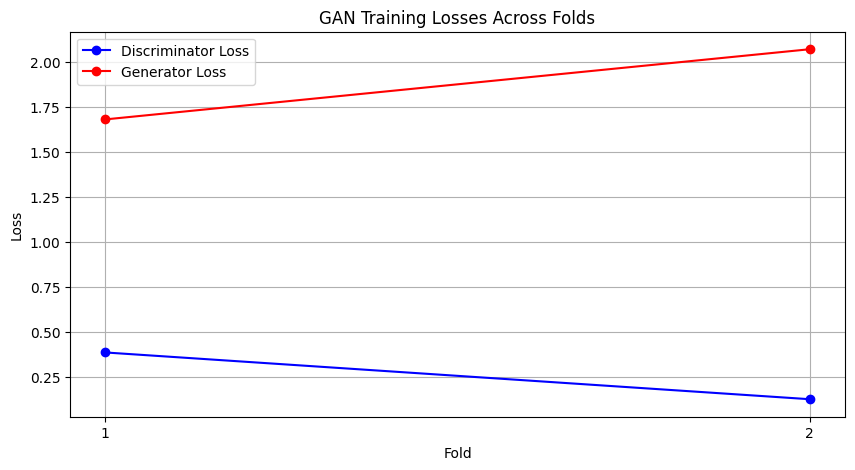

In [9]:
import matplotlib.pyplot as plt
import numpy as np

if 'cross_validation_results' in locals():
    fold_discriminator_losses = cross_validation_results.get('fold_discriminator_losses', [])
    fold_generator_losses = cross_validation_results.get('fold_generator_losses', [])
    n_splits = cross_validation_results.get('config', {}).get('n_splits', len(fold_discriminator_losses))

    folds = np.arange(1, n_splits + 1)

    plt.figure(figsize=(10, 5))

    plt.plot(folds, fold_discriminator_losses, marker='o', linestyle='-', color='b', label='Discriminator Loss')
    plt.plot(folds, fold_generator_losses, marker='o', linestyle='-', color='r', label='Generator Loss')

    plt.xlabel('Fold')
    plt.ylabel('Loss')
    plt.title('GAN Training Losses Across Folds')
    plt.xticks(folds)
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("Cross-validation results not loaded. Please run the previous cell.")

### Load Models

Here's a function to load a saved model state dictionary.

In [6]:
def load_model(model, file_path):
    """Loads a saved model state dictionary."""
    try:
        model.load_state_dict(torch.load(file_path, map_location=torch.device('cpu'))) # Load to CPU first
        print(f"Model loaded successfully from {file_path}")
    except FileNotFoundError:
        print(f"Error: Model file not found at {file_path}")
    except Exception as e:
        print(f"Error loading model from {file_path}: {e}")
    return model

Now, let's load the generator and discriminator models for each fold using the defined function.

In [7]:
# Assuming CONFIG is already defined in the previous cell and contains output_directory
output_dir = CONFIG['output_directory']
n_splits = CONFIG['n_splits']
vocab_size = CONFIG['vocab_size']
d_model = CONFIG['d_model']
nhead = CONFIG['nhead']
num_layers = CONFIG['num_layers']
dim_feedforward = CONFIG['dim_feedforward']
dropout = CONFIG['dropout']

loaded_generators = []
loaded_discriminators = []

for fold in range(n_splits):
    print(f"\nLoading models for Fold {fold + 1}...")
    generator_path = os.path.join(output_dir, f'generator_fold_{fold + 1}.pth')
    discriminator_path = os.path.join(output_dir, f'discriminator_fold_{fold + 1}.pth')

    # Create new instances of the models before loading
    generator = Generator(vocab_size, d_model, nhead, num_layers, dim_feedforward, dropout)
    discriminator = Discriminator(vocab_size, d_model, nhead, num_layers, dim_feedforward, dropout)

    # Load the state dictionaries
    loaded_generator = load_model(generator, generator_path)
    loaded_discriminator = load_model(discriminator, discriminator_path)

    loaded_generators.append(loaded_generator)
    loaded_discriminators.append(loaded_discriminator)

print("\nAll models loaded.")

# You can now access loaded_generators and loaded_discriminators lists
# to work with the models from each fold.


Loading models for Fold 1...
Model loaded successfully from /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/models/generator_fold_1.pth
Model loaded successfully from /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/models/discriminator_fold_1.pth

Loading models for Fold 2...
Model loaded successfully from /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/models/generator_fold_2.pth
Model loaded successfully from /content/drive/MyDrive/Google_AI_Studio/ARCAGI2025/models/discriminator_fold_2.pth

All models loaded.
